In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("mall_customers (1).csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,52,46,49
1,2,Female,35,99,83
2,3,Female,40,80,64
3,4,Male,31,74,83
4,5,Male,47,53,42


In [ ]:
print("Shape:", df.shape)

df.info()

df.isnull().sum()

Shape: (1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              1000 non-null   int64 
 1   Gender                  1000 non-null   object
 2   Age                     1000 non-null   int64 
 3   Annual Income (k$)      1000 non-null   int64 
 4   Spending Score (1-100)  1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,52,46,49
1,2,0,35,99,83
2,3,0,40,80,64
3,4,1,31,74,83
4,5,1,47,53,42


In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,46,49
1,99,83
2,80,64
3,74,83
4,53,42


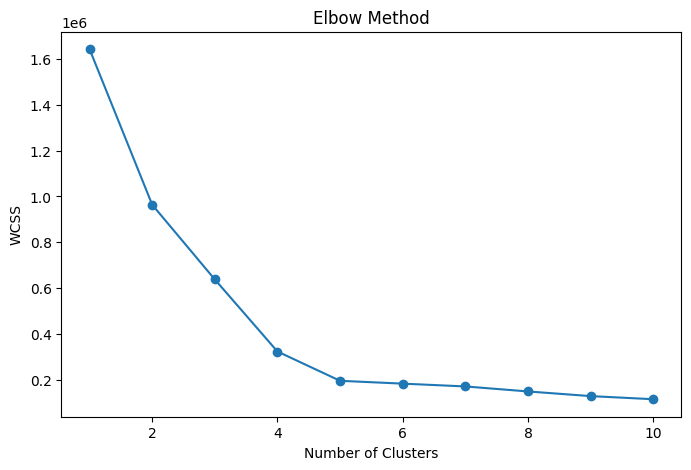

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Create K-Means model
kmeans = KMeans(n_clusters=5, random_state=42)

# Train the model
df["Cluster"] = kmeans.fit_predict(X)

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,52,46,49,4
1,2,0,35,99,83,1
2,3,0,40,80,64,1
3,4,1,31,74,83,1
4,5,1,47,53,42,4


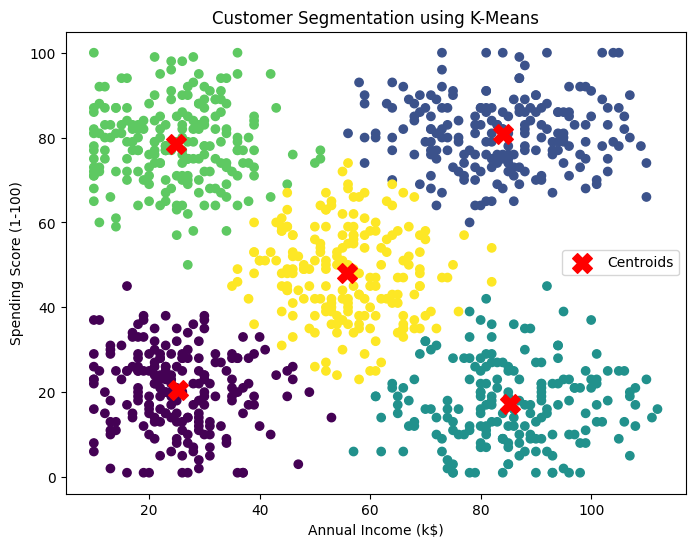

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    s=200,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [ ]:
print(df["Cluster"].value_counts())

Cluster
3    208
0    204
4    201
1    197
2    190
Name: count, dtype: int64


In [ ]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Project completed successfully!")

Project completed successfully!
